In [1]:
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, animation, rc,colors
from IPython.display import Image
rc('animation', html='html5')
import os

import pandas as pd
import matplotlib.dates as mdates

In [2]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [3]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])


In [38]:
path_run = '/data/jvalenti/results/' 
#path_run = '/ocean/atall/MOAD/Model/202410b/oxygen/'
#path_run = '/home/jvalenti/projects/rrg-allen/SalishSea/nowcast-green.202111/'
day = 150
start = datetime(2025,1,1)
make_filename(path_run,start,day, var='biol_T', res='h')

'31may25/SHEM_1h_20250531-20250531_biol_T.nc'

In [39]:
Ox = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_oxygen
diat = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).diatoms
NO3 = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).nitrate
flag = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).flagellates
hbac = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).heterotrophic_bacteria
DOM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_organic_nitrogen
POM = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).particulate_organic_nitrogen

In [40]:
#(imin,imax,jmin,jmax)
regions = {'Jervis':(290,360,610,690),'Sanich':(173,220,325,360),'CSoG':(180,300,450,550),'Dabob Bay':(167,214,120,150), 'Lynch Cove': (120,150,67,76)}
colors_reg={'Jervis':'tab:blue','Sanich':'tab:orange','CSoG':'tab:green','Dabob Bay':'tab:red', 'Lynch Cove': 'tab:purple'}
def mark_region(region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    plt.plot(x, y, color=color,label=region)


/home/jvalenti/MOAD/analysis-jose/.pixi/envs/shem/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


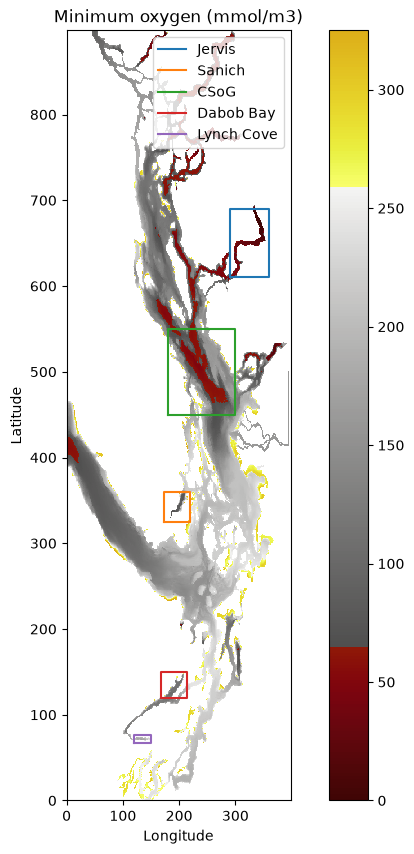

In [41]:
cmap = cmocean.cm.oxy 

colors=['tab:blue','tab:orange','tab:green','tab:red', 'tab:purple']
fig, ax = plt.subplots(figsize=(10,10))
ox_0 = Ox[0,:,:,:]*mask.tmask[0,0,:,:]
oxy_min = ox_0.where(ox_0 != 0).min(skipna=True,dim='deptht')
plt.pcolormesh(oxy_min,cmap=cmap,vmax =325,vmin=0)
plt.colorbar()
f = 1.0/np.cos(49*np.pi/180)
for i,region in enumerate(regions.keys()):
    mark_region(region,color=colors[i])
plt.legend()
plt.gca().set_aspect(f)
plt.title('Minimum oxygen (mmol/m3)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.ylim(0,200)
plt.show()

In [42]:
def hypoxia_count(dia,region=None,regions=None,var = 'biol_T'):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        mbath = mask.mbathy[0,:,:].isel(x=slice(x0,x1),y=slice(y0,y1))-1
    else:
        mbath = mask.mbathy[0,:,:]-1
    total_area = np.sum(mbath>0)
    with xr.open_dataset(path_run+make_filename(path_run,start,dia, var=var, res='h')) as ds:
        if region is not None:
            x0, x1, y0, y1 = regions[region]
            Ox = ds.dissolved_oxygen.isel(time_counter=0,y=slice(y0, y1), x=slice(x0, x1))
        else:
            region = 'full domain'
            Ox = ds.dissolved_oxygen.isel(time_counter=0)
    ox_0 = Ox.isel(deptht=mbath)
    count=np.sum((ox_0 > 0) & (ox_0 < 65))
    return count/total_area.values

def oxy_mean(dia,region=None,regions=None):
    if region is not None:
        x0, x1, y0, y1 = regions[region]
        mbath = mask.mbathy[0,:,:].isel(x=slice(x0,x1),y=slice(y0,y1))-1
    else:
        mbath = mask.mbathy[0,:,:]-1
    with xr.open_dataset(path_run+make_filename(path_run,start,dia, var='biol_T', res='h')) as ds:
        if region is not None:
            x0, x1, y0, y1 = regions[region]
            Ox = ds.dissolved_oxygen.isel(time_counter=0,y=slice(y0, y1), x=slice(x0, x1))
        else:
            region = 'full domain'
            Ox = ds.dissolved_oxygen.isel(time_counter=0)
    ox_0 = Ox.isel(deptht=mbath)
    count = ox_0.where(ox_0 > 0).mean().values
    return count 

In [43]:
def progress_bar(iterable, total=None, length=30):
    total = total or len(iterable)
    for i, item in enumerate(iterable, 1):
        filled = int(length * i / total)
        bar = '█' * filled + '-' * (length - filled)
        print(f'\r|{bar}| {i}/{total}', end='', flush=True)
        yield item
    print()

In [44]:
# #path_run = '/data/jvalenti/results/' 
# path_run = '/results2/SalishSea/nowcast-green.202111/'
# region = None
# start = datetime(2023,1,1)
# Len = 1096
# count_hypox = np.full(Len,np.nan)

# for dia in progress_bar(range(Len)):
#     count_hypox[dia] = oxy_mean(dia)
    
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/meano2_full_2325.npy', count_hypox)

In [45]:
# path_run = '/data/jvalenti/results/' 
# #path_run = '/results2/SalishSea/nowcast-green.202111/'
# region = None
# start = datetime(2023,1,1)
# Len = 1096
# count_hypox = np.full((len(regions), Len), np.nan)

# for i, region in enumerate(regions.keys()):
#     print(region)
#     for dia in progress_bar(range(Len)):
#         count_hypox[i, dia] = oxy_mean(dia,region=region, regions=regions)
    
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/shem_meano2_regions_2325.npy', count_hypox)

In [46]:
# #path_run = '/home/jvalenti/scratch/run_SHEM/long_run/' 
# region = None
# start = datetime(2023,1,1)
# Len = 730
# count_hypox = np.full((len(regions), Len), np.nan)

# for i, region in enumerate(regions.keys()):
#     print(region)
#     for dia in range(Len):
#         if dia==424:
#             continue
#         else: 
#             count_hypox[i, dia] = oxy_mean(dia,region=region, regions=regions)

# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/meano2_regions.npy', count_hypox)

In [47]:
# Len = 1096
# path_run = '/data/jvalenti/results/' 
# start = datetime(2023,1,1)
# count_hypox = np.full(Len,np.nan)

# for dia in progress_bar(range(Len)):
#     count_hypox[dia] = 100*hypoxia_count(dia)
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_shem_hypox_full_2325.npy', count_hypox)


In [48]:
# Len = 1096
# path_run = '/results2/SalishSea/nowcast-green.202111/'
# start = datetime(2023,1,1)
# count_hypox = np.full((len(regions), Len), np.nan)

# for i, region in enumerate(regions.keys()):
#     print(region)
#     for dia in progress_bar(range(Len)):
#         count_hypox[i,dia] = 100*hypoxia_count(dia,var = 'chem_T')
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_reg_2325.npy', count_hypox)


In [49]:
# Len = 1096
# path_run = '/data/jvalenti/results/' 
# start = datetime(2023,1,1)
# count_hypox = np.full((len(regions), Len), np.nan)

# for i, region in enumerate(regions.keys()):
#     print(region)
#     for dia in progress_bar(range(Len)):
#         count_hypox[i,dia] = 100*hypoxia_count(dia,region=region,regions=regions,var='biol_T')
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_shem_hypox_reg_2325.npy', count_hypox)

In [50]:
# Len = 1096
# path_run = '/results2/SalishSea/nowcast-green.202111/'
# start = datetime(2023,1,1)
# count_hypox = np.full((len(regions), Len), np.nan)

# for i, region in enumerate(regions.keys()):
#     print(region)
#     for dia in progress_bar(range(Len)):
#         count_hypox[i,dia] = 100*hypoxia_count(dia,region=region,regions=regions,var='chem_T')
# np.save('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_regions_2325.npy', count_hypox)

In [51]:
count_hypox_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_shem_hypox_reg_2325.npy')
count_hypox = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_shem_hypox_full_2325.npy')

count_hypox_reg_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_reg_2325.npy')
count_hypox_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_full_2325.npy')

count_hypox_reg_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_oxy_hypox_regions.npy')
count_hypox_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_oxy_hypox_full.npy')[4,:]


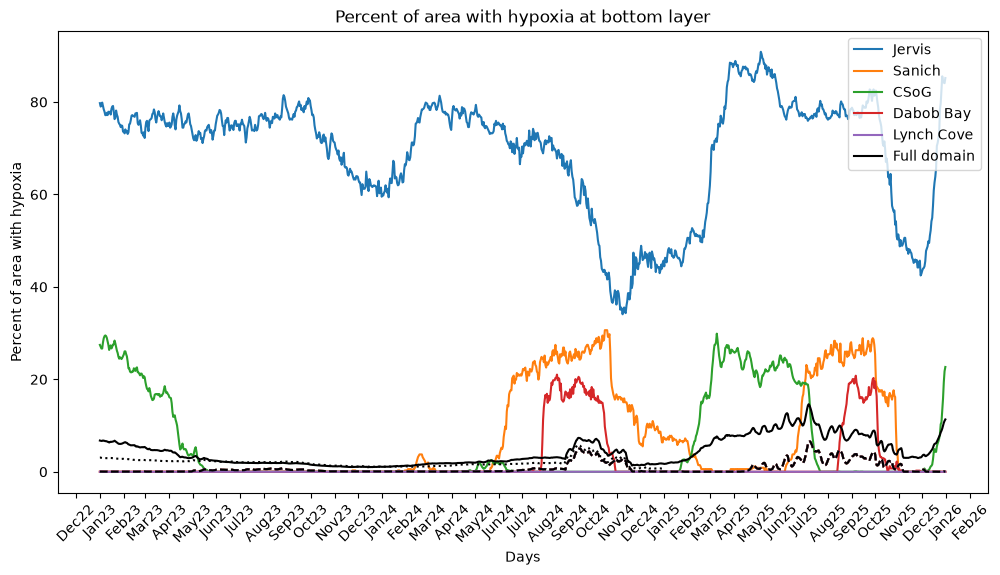

In [52]:
fig = plt.figure(figsize=(12,6))
time = pd.date_range(start='2023-01-01',end='2024-12-29',freq='D')
time2 = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')

for i, region in enumerate(regions.keys()):
    plt.plot(time2, count_hypox_reg[i,:], label=region, color=colors_reg[region], linestyle='-')
    plt.plot(time2, count_hypox_reg_2021[i,:],  color=colors_reg[region], linestyle='--')
    #plt.plot(time, count_hypox_reg_oxy[i,:729],  color=colors_reg[region], linestyle=':')
    

count = count_hypox[~np.isnan(count_hypox[:])]
count2 = count_hypox_2021[~np.isnan(count_hypox_2021[:])]
count3 = count_hypox_oxy[~np.isnan(count_hypox_oxy[:])]

plt.plot(time2, count, label='Full domain', color='black', linestyle='-')
plt.plot(time2, count2,  color='black', linestyle='--')
plt.plot(time, count3, color='black', linestyle=':')

plt.xlabel('Days')
plt.ylabel('Percent of area with hypoxia')
plt.title('Percent of area with hypoxia at bottom layer')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
plt.legend(loc=1)

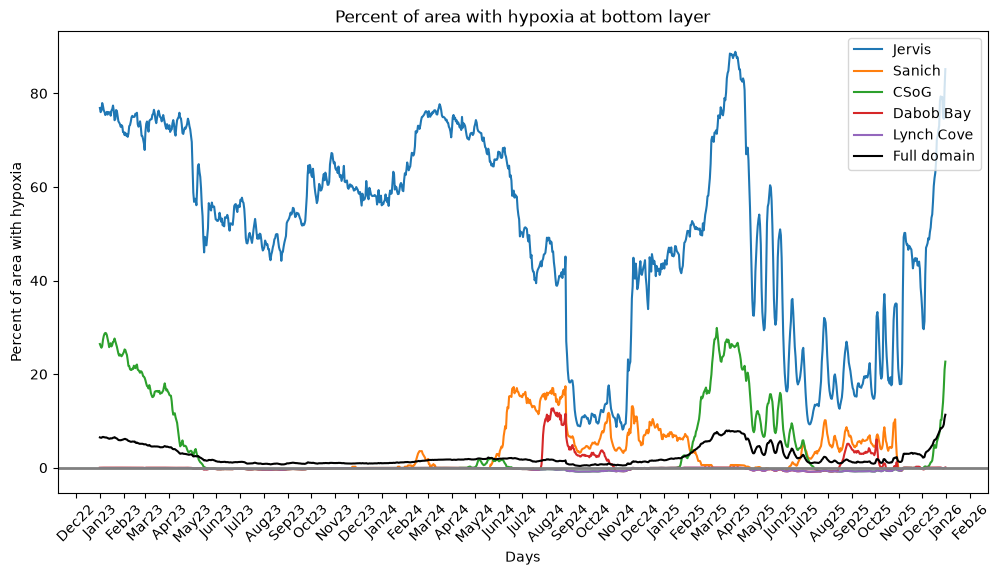

In [53]:
fig = plt.figure(figsize=(12,6))
time = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')


for i, region in enumerate(regions.keys()):

    reg_count = count_hypox_reg[i,~np.isnan(count_hypox_reg[i,:])]+1
    reg_count2 = count_hypox_reg_2021[i,~np.isnan(count_hypox_reg[i,:])]+1

    plt.plot(time, (reg_count-reg_count2)/reg_count2, label=region, color=colors_reg[region], linestyle='-')
    #plt.plot(time, reg_count2,  color=colors_reg[region], linestyle='--')
    #plt.plot(time, (reg_count3-reg_count2)/reg_count2,  color=colors_reg[region], linestyle=':')

count = count_hypox[~np.isnan(count_hypox[:])]+1
count2 = count_hypox_2021[~np.isnan(count_hypox_2021[:])]+1

plt.plot(time, (count-count2)/count2, label='Full domain', color='black', linestyle='-')
#plt.plot(time, count2,  color='black', linestyle='--')

plt.xlabel('Days')
plt.ylabel('Percent of area with hypoxia')
plt.title('Percent of area with hypoxia at bottom layer')
plt.axhline(0, color='grey', linewidth=2)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
plt.legend(loc=1)

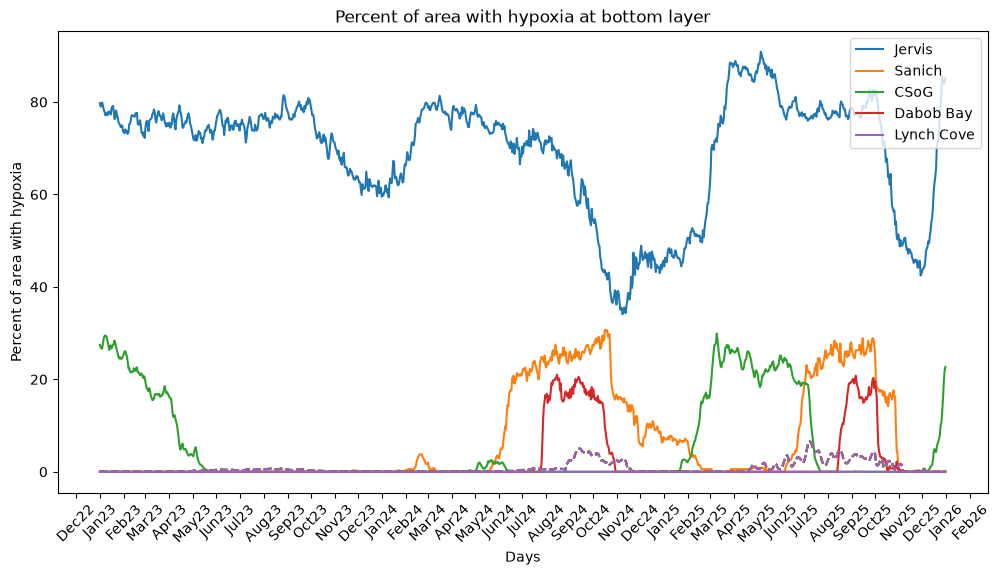

In [54]:
fig = plt.figure(figsize=(12,6))
#time = pd.date_range(start='2023-01-01',end='2024-12-29',freq='D')

for i, region in enumerate(regions.keys()):
    reg_count = count_hypox_reg[i,~np.isnan(count_hypox_reg[i,:])]
    reg_count2 = count_hypox_reg_2021[i,~np.isnan(count_hypox_reg[i,:])]

    plt.plot(time, reg_count, label=region, color=colors_reg[region], linestyle='-')
    plt.plot(time, reg_count2,  color=colors_reg[region], linestyle='--')
count_hypox[424]=np.nan
count = count_hypox[~np.isnan(count_hypox[:])]
count2 = count_hypox_2021[~np.isnan(count_hypox_2021[:])]
count3 = count_hypox_oxy[~np.isnan(count_hypox_oxy[:])]

#plt.plot(time, count, label='Full domain', color='black', linestyle='-')
#plt.plot(time, count2, label='Full domain', color='black', linestyle='--')
#plt.plot(time, count3, label='Full domain', color='black', linestyle='-.')

plt.xlabel('Days')
plt.ylabel('Percent of area with hypoxia')
plt.title('Percent of area with hypoxia at bottom layer')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
plt.legend(loc=1)

In [55]:
# fig = plt.figure(figsize=(12,6))
# time = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')

# for i, region in enumerate(regions.keys()):
#     reg_count = count_hypox_reg_2021[i,~np.isnan(count_hypox_reg_2021[i,:])]
#     plt.plot(time, reg_count, label=region, color=colors_reg[region])
# count = count_hypox_2021[~np.isnan(count_hypox_2021[:])]
# plt.plot(time, count, label='Full domain', color='black', linestyle='--')
# plt.xlabel('Days')
# plt.ylabel('Percent of area with hypoxia')
# plt.title('Percent of area with hypoxia at bottom layer v202111')
# ax = plt.gca()
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
# plt.xticks(rotation=45)
# plt.legend(loc=1)

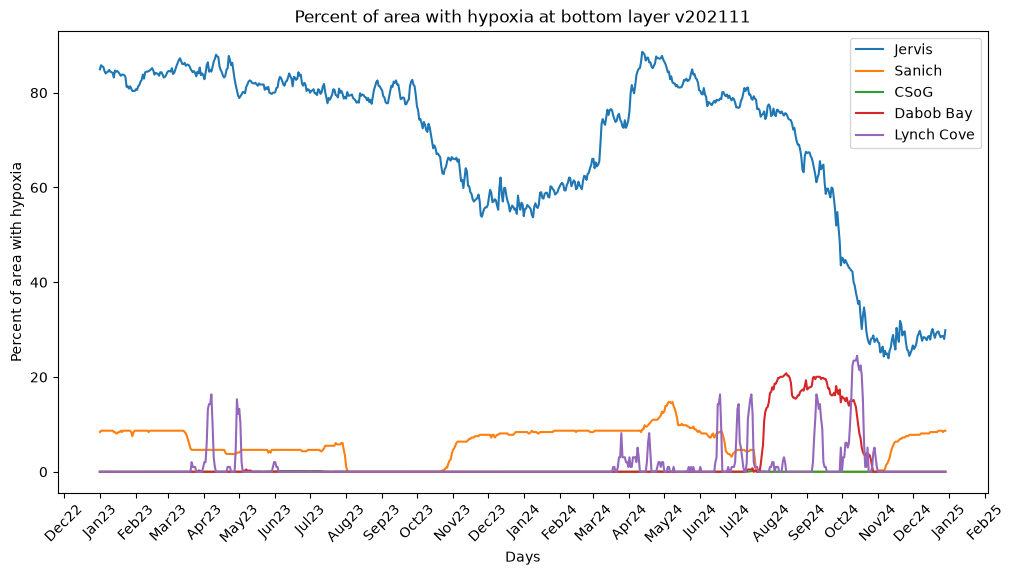

In [56]:
count_hypox_reg_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_oxy_hypox_regions.npy')

fig = plt.figure(figsize=(12,6))
time = pd.date_range(start='2023-01-01',end='2024-12-29',freq='D')

for i, region in enumerate(regions.keys()):
    count_hypox_reg_oxy[i,424 ]=np.nan
    reg_count = count_hypox_reg_oxy[i,~np.isnan(count_hypox_reg_oxy[i,:])]
    plt.plot(time, reg_count, label=region, color=colors_reg[region])

plt.xlabel('Days')
plt.ylabel('Percent of area with hypoxia')
plt.title('Percent of area with hypoxia at bottom layer v202111')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
plt.legend(loc=1)

In [57]:
mean_oxy_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/meano2_full_2325.npy')
mean_oxy_reg_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/meano2_regions_2325.npy')

mean_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/oxy_meano2_full_2325.npy')
mean_oxy_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/shem_meano2_regions_2325.npy')

mean_oxy_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/oxy_meano2_full.npy')
mean_oxy_reg_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/oxy_meano2_regions.npy')

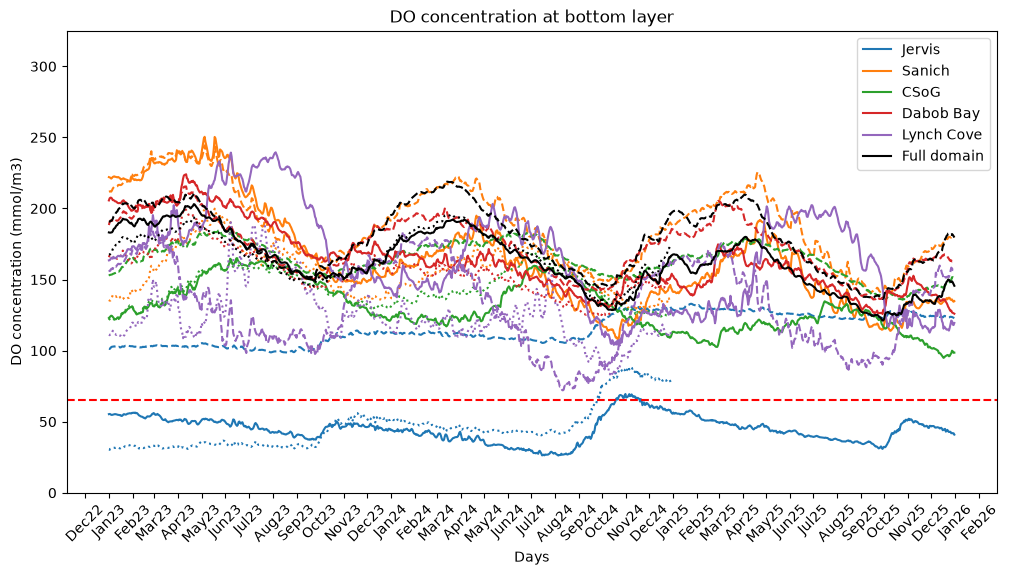

In [58]:
fig = plt.figure(figsize=(12,6))
time = pd.date_range(start='2023-01-01',end='2024-12-29',freq='D')
time2 = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')


for i, region in enumerate(regions.keys()):
    reg_count = mean_oxy_reg[i,~np.isnan(mean_oxy_reg[i,:])]
    reg_count3 = mean_oxy_reg_oxy[i,~np.isnan(mean_oxy_reg_oxy[i,:])]
    reg_count2 = mean_oxy_reg_2021[i,~np.isnan(mean_oxy_reg_2021[i,:])]
    
    plt.plot(time2, reg_count, label=region, color=colors_reg[region],linestyle='-')
    plt.plot(time2, reg_count2, color=colors_reg[region],linestyle='--')
    plt.plot(time, reg_count3, color=colors_reg[region],linestyle=':')

count = mean_oxy[~np.isnan(mean_oxy[:])]
count2 = mean_oxy_2021[~np.isnan(mean_oxy_2021[:])]
count3 = mean_oxy_oxy[~np.isnan(mean_oxy_oxy[:])]

plt.plot(time2, count, label='Full domain', color='black',linestyle='-')
plt.plot(time2, count2,  color='black',linestyle='--')
plt.plot(time, count3,  color='black',linestyle=':')

plt.xlabel('Days')
plt.ylim(0,325)
plt.axhline(65, color='red', linestyle='--')
plt.ylabel('DO concentration (mmol/m3)')
plt.title('DO concentration at bottom layer')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
plt.legend(loc=1)

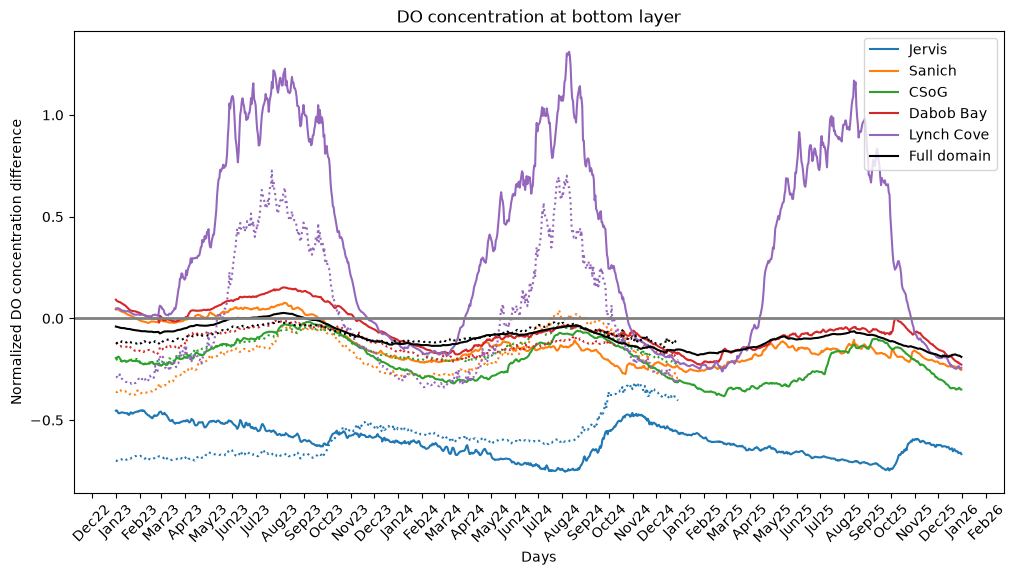

In [59]:
fig,axs = plt.subplots(1,figsize=(12,6))
time = pd.date_range(start='2023-01-01',end='2024-12-29',freq='D')

for i, region in enumerate(regions.keys()):

    reg_count = mean_oxy_reg[i,~np.isnan(mean_oxy_reg[i,:])]
    reg_count3 = mean_oxy_reg_oxy[i,~np.isnan(mean_oxy_reg_oxy[i,:])]
    reg_count2 = mean_oxy_reg_2021[i,~np.isnan(mean_oxy_reg_2021[i,:])]
    
    plt.plot(time2, (reg_count-reg_count2)/reg_count2, label=region, color=colors_reg[region],linestyle='-')
    plt.plot(time, (reg_count3-reg_count2[:729])/reg_count2[:729], color=colors_reg[region],linestyle=':')

count = mean_oxy[~np.isnan(mean_oxy[:])]
count2 = mean_oxy_2021[~np.isnan(mean_oxy_2021[:])]
count3 = mean_oxy_oxy[~np.isnan(mean_oxy_oxy[:])]

plt.plot(time2, (count-count2)/count2, label='Full domain', color='black',linestyle='-')
plt.plot(time, (count3-count2[:729])/count2[:729],  color='black',linestyle=':')

plt.xlabel('Days')
#plt.ylim(0,325)
plt.axhline(0, color='grey', linewidth=2)
plt.ylabel('Normalized DO concentration difference')
plt.title('DO concentration at bottom layer')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
plt.xticks(rotation=45)
plt.legend(loc=1)

In [60]:
from salishsea_tools import evaltools as et
import datetime as dt

In [61]:
df = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/Lynch_cove/lynch.csv',index_col=False)

df['dtUTC'] = pd.to_datetime(df['Field_Collection_Date'] + ' ' + df['Field_Collection_Time'],format='mixed')

In [62]:
df = df.rename(columns={"Calculated_Latitude_Decimal_Degrees_NAD83HARN": "Lat", "Calculated_Longitude_Decimal_Degrees_NAD83HARN": "Lon",'Depth_Value':'Z'})

df = df[df['Result_Value']>0]
df = df[df['Z']>0].reset_index(drop=True)

df['dtUTC'] = df['dtUTC'].dt.tz_localize(None)

In [63]:
path = '/results2/SalishSea/nowcast-green.202111'
filemap={'dissolved_oxygen':'biol_T'}

fdict={'biol_T':1}
path = f'/data/jvalenti/results'
mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

start_date = dt.datetime(2024,1,1) 
end_date = dt.datetime(2024,12,31) 

In [64]:
# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
# data.to_csv('lynch_2024_SHEM.csv')

# path = '/results2/SalishSea/nowcast-green.202111'
# filemap={'dissolved_oxygen':'chem_T'}
# fdict={'chem_T':1}

# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('lynch_2024_20211.csv')

# path = '/ocean/atall/MOAD/Model/202410b/oxygen/'
# filemap={'dissolved_oxygen':'chem_T'}
# fdict={'chem_T':24}

# data=et.matchData(df,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('lynch_2024_202410.csv')

In [65]:
#Combine all versions in single file
data= pd.read_csv('lynch_2024_SHEM.csv')
data = data.rename(columns={'mod_dissolved_oxygen':'SHEM'})
data2= pd.read_csv('lynch_2024_20211.csv')
data['v202111']=data2['mod_dissolved_oxygen']
data3= pd.read_csv('lynch_2024_202410.csv')
data['v202410']=data3['mod_dissolved_oxygen']

data.to_csv('lynch_2024_all.csv')

In [66]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()

    return rmse_val, bias,WI

In [67]:
import matplotlib
from permetrics.regression import RegressionMetric

In [68]:
def plot_o2(ax,data,name = "SHEM"):
    model = np.array(data[name])
    obs = np.array(data['Result_Value'])*31.25
    mask_N = (obs > 0) & (~np.isnan(model))
    rmse, bias, WI = calculate_rmse_bias(obs[mask_N], model[mask_N])

    ax.scatter(obs[mask_N],model[mask_N], alpha=0.6)
    ax.set_xlabel('O2_observed')
    ax.set_title(f'Oxygen: Model {name} vs Observed 2023')

    ax.plot(np.linspace(0, 400),np.linspace(0, 400),'r--')
    ax.text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=ax.transAxes,color='red')
    ax.set_xlim(-20,400)

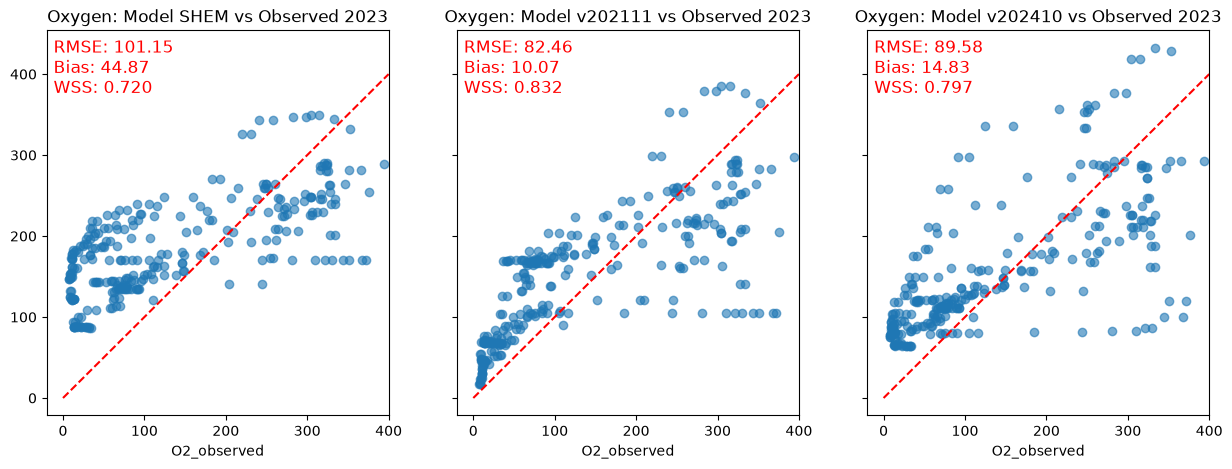

In [69]:
data = data.rename(columns={'mod_dissolved_oxygen':'SHEM'})
fig,axs = plt.subplots(1,3,figsize=(15,5),sharey=True)
plot_o2(axs[0],data,'SHEM')
plot_o2(axs[1],data,'v202111')
plot_o2(axs[2],data,'v202410')